In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

MASTER = 'Pathways Master.xlsx'

In [57]:
def make_df(tab):
    df = pd.read_excel(MASTER, tab, usecols=range(0, 12))[:16] #Read in data from a tab, use just columns w raw data
    df = df.rename(columns={'Unnamed: 0': 'Community Colleges'}) #Name indx column
    df.set_index('Community Colleges', inplace=True) #set indx
    df = df.astype(float) #make all values floats
    return df

In [58]:
total_ch = make_df('Credit Hours') # Total Credit Hours per Degree
pct_as = make_df('% Credit Hours') #Percent of AS that Transfers
curr_comp = make_df('Curricular Complexity') # Curricular Complexity
cost = make_df('Cost') # Cost

In [59]:
def make_graph(df, title, ylabel, filename):
    plt.figure(figsize=(10, 6))
    
    # make boxplot of just transfer degrees
    sns.boxplot(data=df.loc['Berkshire':], linewidth=1.5, zorder=1)
    
    # overlay (z=2) scatterplot with just res degrees 
    if ylabel != 'Percent of AS':
        plt.scatter(df.columns, df.loc['Resident'], color='teal', label='Resident Degrees', zorder=2)
    
    #Customization!! :D
    if filename=='cost':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend()
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(fontsize=10, rotation=90)
    plt.yticks(fontsize=10)
    plt.savefig(f'images/{filename}.png', bbox_inches = 'tight')
    plt.show()

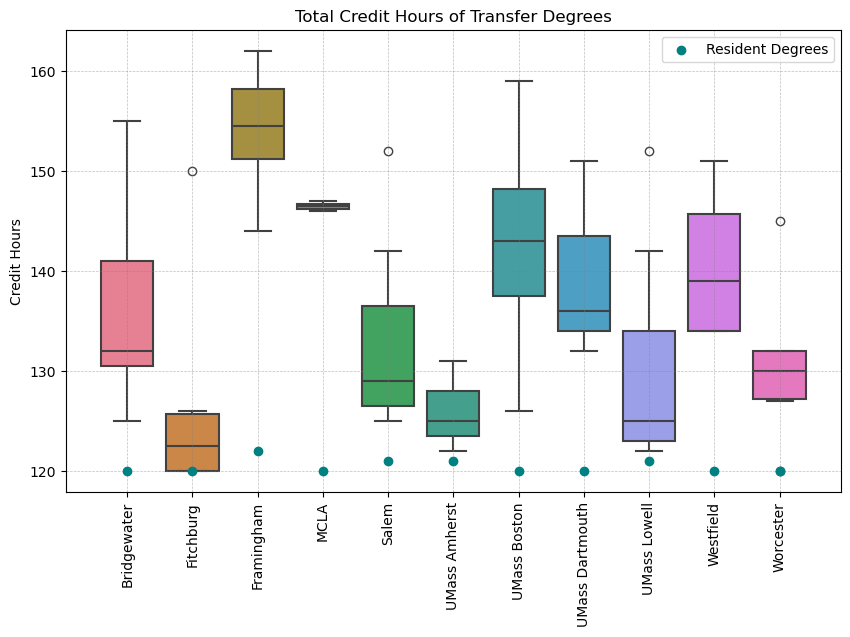

In [60]:
make_graph(total_ch, 'Total Credit Hours of Transfer Degrees', 'Credit Hours', 'total_ch')

C:\Users\rfbay\AppData\Local\Temp\ipykernel_17028\1680991307.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


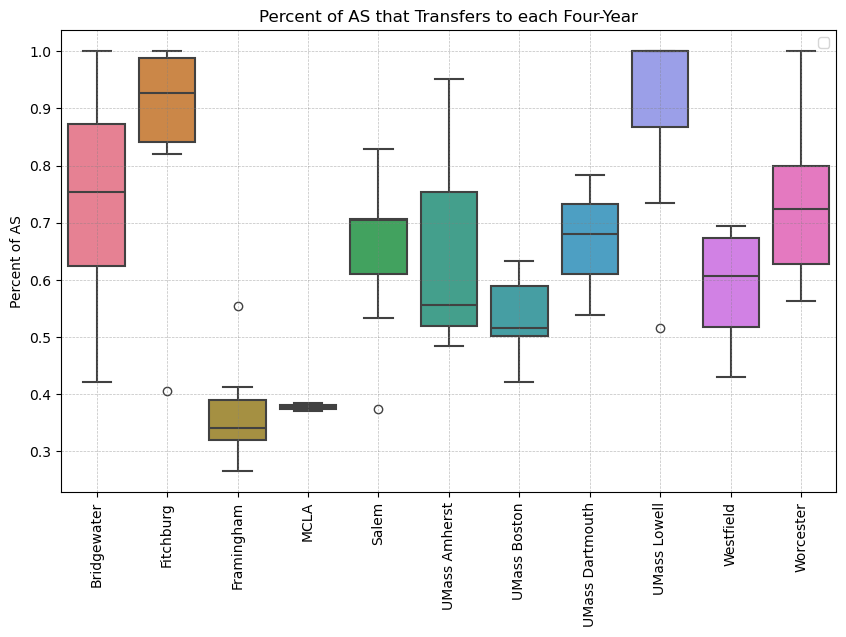

In [61]:
make_graph(pct_as, 'Percent of AS that Transfers to each Four-Year', 'Percent of AS', 'pct_as')

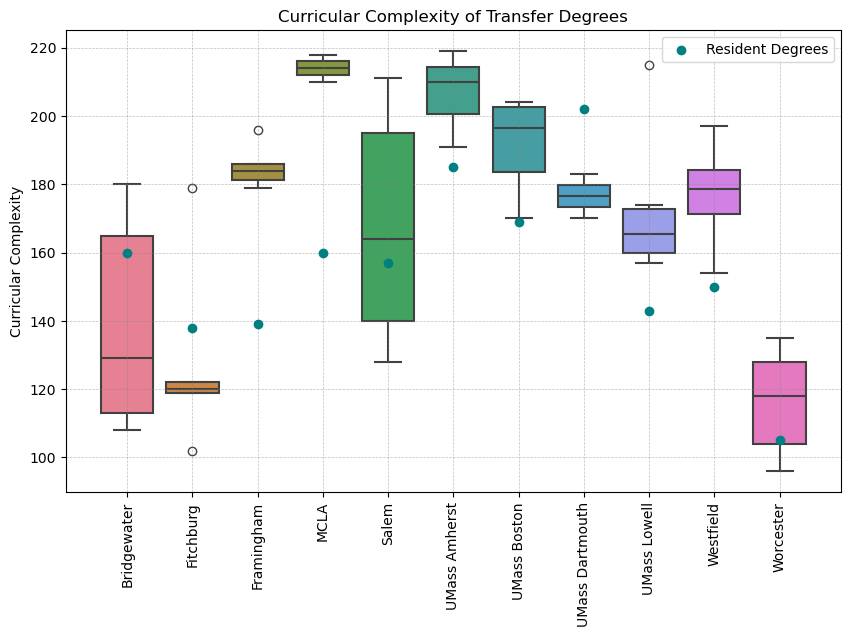

In [62]:
make_graph(curr_comp, 'Curricular Complexity of Transfer Degrees', 'Curricular Complexity', 'curr_comp')

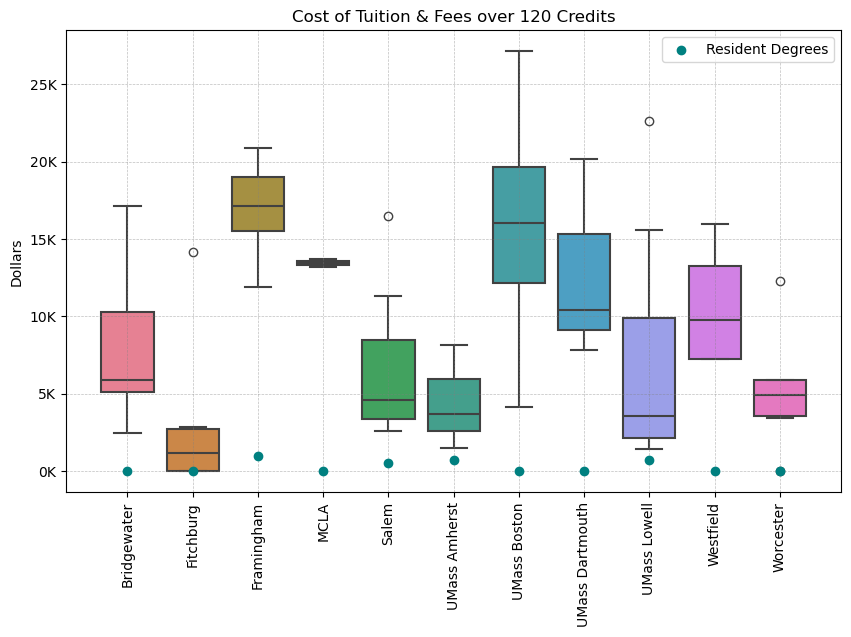

In [70]:
make_graph(cost, 'Cost of Tuition & Fees over 120 Credits', 'Dollars', 'cost')

In [64]:

pct_as_melt = pct_as.melt(var_name='Category', value_name='pct_as')
total_ch_melt = total_ch.melt(var_name='Category', value_name='total_ch')
curr_comp_melt = curr_comp.melt(var_name='Category', value_name='curr_comp')
cost_melt = cost.melt(var_name='Category', value_name='cost')
cat_df = pd.concat([pct_as_melt, total_ch_melt['total_ch'], curr_comp_melt['curr_comp'], cost_melt['cost']], axis=1)

In [65]:
cat_df

,Category,pct_as,total_ch,curr_comp,cost
0,Bridgewater,1.000000,120.0,160.0,0.000000
1,Bridgewater,NaN,NaN,NaN,NaN
2,Bridgewater,0.739130,130.0,165.0,4889.166667
3,Bridgewater,0.508197,149.0,180.0,14178.583330
4,Bridgewater,0.753623,131.0,113.0,5378.083333
...,...,...,...,...,...
171,Worcester,NaN,NaN,NaN,NaN
172,Worcester,NaN,NaN,NaN,NaN
173,Worcester,1.000000,120.0,96.0,0.000000
174,Worcester,0.562500,145.0,NaN,12277.083330


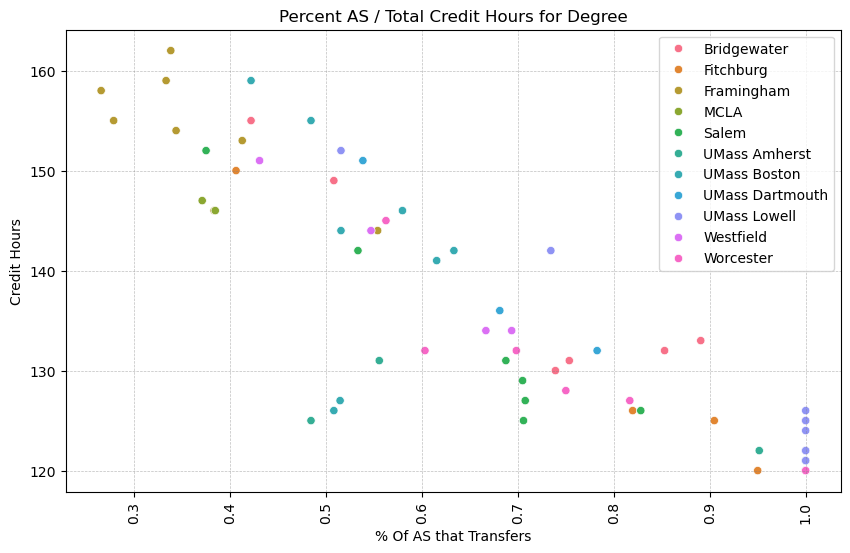

In [66]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cat_df['pct_as'], y=cat_df['total_ch'], hue=cat_df['Category'])
# plt.scatter(pct_as, total_ch)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.title('Percent AS / Total Credit Hours for Degree')
plt.ylabel('Credit Hours')
plt.xlabel('% Of AS that Transfers')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.savefig('images/pct-total.png', bbox_inches = 'tight')
plt.show()

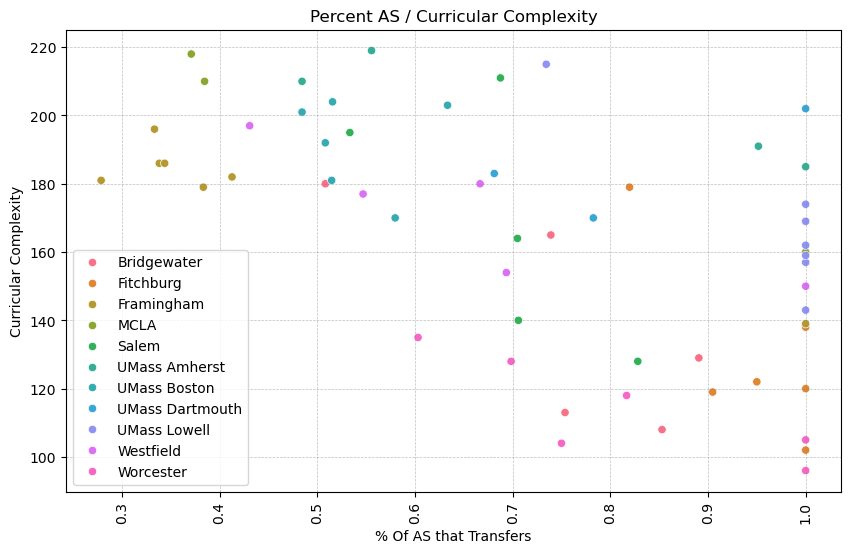

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cat_df['pct_as'], y=cat_df['curr_comp'], hue=cat_df['Category'])
# plt.scatter(pct_as, total_ch)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.title('Percent AS / Curricular Complexity')
plt.ylabel('Curricular Complexity')
plt.xlabel('% Of AS that Transfers')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.savefig('images/pct-curr_comp.png', bbox_inches = 'tight')
plt.show()

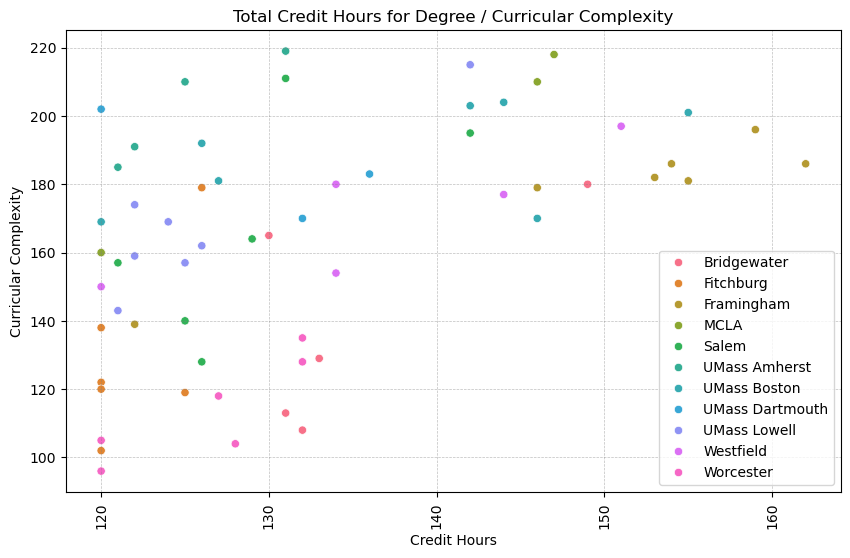

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cat_df['total_ch'], y=cat_df['curr_comp'], hue=cat_df['Category'])
# plt.scatter(pct_as, total_ch)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.title('Total Credit Hours for Degree / Curricular Complexity')
plt.ylabel('Curricular Complexity')
plt.xlabel('Credit Hours')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.savefig('images/total-curr_comp.png', bbox_inches = 'tight')
plt.show()

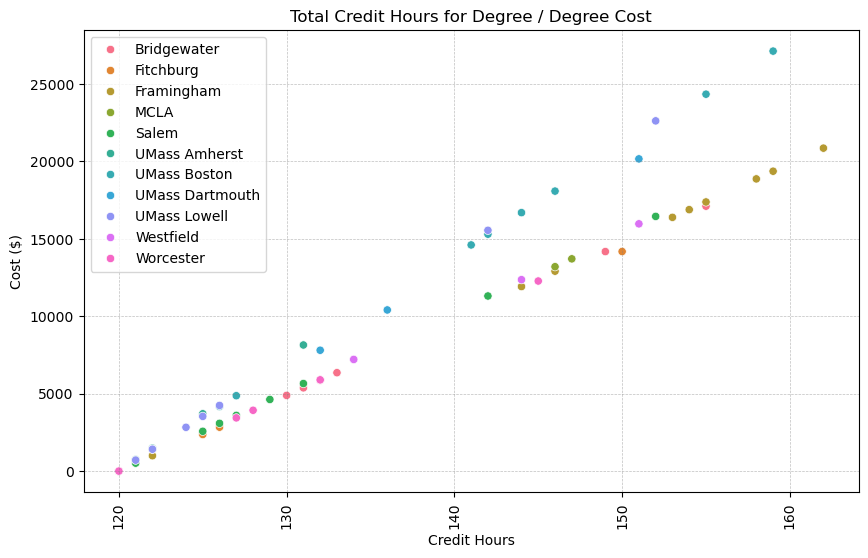

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cat_df['total_ch'], y=cat_df['cost'], hue=cat_df['Category'])
# plt.scatter(pct_as, total_ch)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.title('Total Credit Hours for Degree / Degree Cost')
plt.ylabel('Cost ($)')
plt.xlabel('Credit Hours')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.savefig('images/total-cost.png', bbox_inches = 'tight')
plt.show()